In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random 
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from keras.datasets import mnist
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.datasets import mnist


In [3]:
from tensorflow.keras.datasets import mnist
(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_y_one = train_y
test_y_one = test_y

In [4]:
train_y_one.shape
test_y_one.shape

(10000,)

In [5]:
print(train_X.shape)
print(train_y.shape)
print(test_X.shape)
print(test_y.shape)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [6]:
# Creating a small list so we can index onto our training labels 
class_names = ["Zero", "One", "Two", "Three", "Four", "Five", "Six", "Seven", "Eight", "Nine"]
len(class_names) 


10

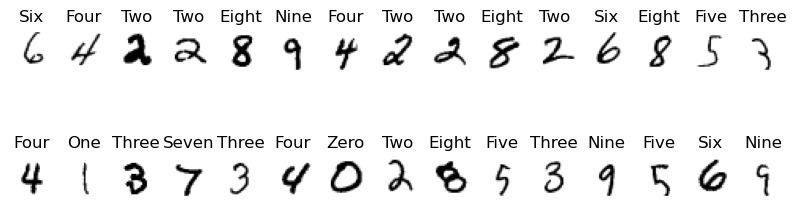

In [7]:
plt.figure(figsize=(10, 3))
for i in range(30):
    ax = plt.subplot(2, 15, i + 1)
    rand_index = random.choice(range(len(train_X)))
    # Reshape the image back to 2D array
    image = train_X[rand_index].reshape(28, 28)
    plt.imshow(image, cmap=plt.cm.binary)
    # Display the class name or label
    plt.title(class_names[train_y[rand_index]]) 
    plt.axis('off')  # Correct method to turn off the axis
    
    
    


In [8]:
import tensorflow as tf
train_y = tf.keras.utils.to_categorical(train_y, 10)/255.0
test_y =  tf.keras.utils.to_categorical(test_y, 10)/255.0

train_X = train_X.reshape((train_X.shape[0], -1))
test_X = test_X.reshape((test_X.shape[0], -1))


In [10]:
# Initialize KNN classifier
knn = KNeighborsClassifier()

# Define parameters to tune
params = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'kd_tree', 'ball_tree']
}

best_accuracy = 0
best_params = {}

# Hyperparameter tuning using alorgithm ball_tree
for n_neighbors in params['n_neighbors']:
    for weights in params['weights']:    
                knn.set_params(n_neighbors=n_neighbors, weights=weights, algorithm= 'ball_tree', leaf_size = 30)
                knn.fit(train_X, train_y_one)
                y_pred = knn.predict(test_X)
                accuracy = accuracy_score(test_y_one, y_pred)
                print(f"Parameters: n_neighbors={n_neighbors}, weights={weights}, algorithm= 'ball_tree', leaf_size = 30")
                print(f"Accuracy: {accuracy}")
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_params = {'n_neighbors': n_neighbors, 'weights': weights, 'algorithm': 'ball_tree', 'leaf_size': 30}

print("The Best parameters-", best_params)
print("The Best accuracy is-", best_accuracy)

neighbors = [x[0] for x in accuracy_results]
weights = [x[1] for x in accuracy_results]
accuracies = [x[4] for x in accuracy_results]

plt.figure(figsize=(10, 5))
plt.scatter(neighbors, accuracies, color='blue')
for i, txt in enumerate(weights):
    plt.annotate(txt, (neighbors[i], accuracies[i]))

plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('KNN Hyperparameter Tuning Results')
plt.grid(True)
plt.show()

Parameters: n_neighbors=3, weights=uniform, algorithm= 'ball_tree', leaf_size = 30
Accuracy: 0.9705
Parameters: n_neighbors=3, weights=distance, algorithm= 'ball_tree', leaf_size = 30
Accuracy: 0.9717
Parameters: n_neighbors=5, weights=uniform, algorithm= 'ball_tree', leaf_size = 30
Accuracy: 0.9688
Parameters: n_neighbors=5, weights=distance, algorithm= 'ball_tree', leaf_size = 30
Accuracy: 0.9691
Parameters: n_neighbors=7, weights=uniform, algorithm= 'ball_tree', leaf_size = 30
Accuracy: 0.9694
Parameters: n_neighbors=7, weights=distance, algorithm= 'ball_tree', leaf_size = 30
Accuracy: 0.97
Parameters: n_neighbors=10, weights=uniform, algorithm= 'ball_tree', leaf_size = 30
Accuracy: 0.9665
Parameters: n_neighbors=10, weights=distance, algorithm= 'ball_tree', leaf_size = 30
Accuracy: 0.9684
The Best parameters- {'n_neighbors': 3, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 30}
The Best accuracy is- 0.9717


NameError: name 'accuracy_results' is not defined

In [ ]:

best_accuracy = 0
best_params = {}

# Hyperparameter tuning using alorgithm kd_tree
for n_neighbors in params['n_neighbors']:
    for weights in params['weights']:    
                knn.set_params(n_neighbors=n_neighbors, weights=weights, algorithm= 'kd_tree', leaf_size = 30)
                knn.fit(train_X, train_y_one)
                y_pred = knn.predict(test_X)
                accuracy = accuracy_score(test_y_one, y_pred)
                print(f"Parameters: n_neighbors={n_neighbors}, weights={weights}, algorithm= 'kd_tree', leaf_size = 30")
                print(f"Accuracy: {accuracy}")
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_params = {'n_neighbors': n_neighbors, 'weights': weights, 'algorithm': 'kd_tree', 'leaf_size': 30}

print("The Best parameters-", best_params)
print("The Best accuracy is -", best_accuracy)

Parameters: n_neighbors=3, weights=uniform, algorithm= 'kd_tree', leaf_size = 30
Accuracy: 0.9705
Parameters: n_neighbors=3, weights=distance, algorithm= 'kd_tree', leaf_size = 30
Accuracy: 0.9717
Parameters: n_neighbors=5, weights=uniform, algorithm= 'kd_tree', leaf_size = 30
Accuracy: 0.9688
Parameters: n_neighbors=5, weights=distance, algorithm= 'kd_tree', leaf_size = 30
Accuracy: 0.9691
Parameters: n_neighbors=7, weights=uniform, algorithm= 'kd_tree', leaf_size = 30
Accuracy: 0.9694
Parameters: n_neighbors=7, weights=distance, algorithm= 'kd_tree', leaf_size = 30
Accuracy: 0.97
Parameters: n_neighbors=10, weights=uniform, algorithm= 'kd_tree', leaf_size = 30
Accuracy: 0.9665
